# Chapter 11.2 -- Association Rules and Market Basket Analysis

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 11.1 grouped the rows of a table. This part asks a different question of a store's receipts: which items tend to be bought together, how often, and whether the pattern is worth acting on. It recaps Chapter 9's support, confidence and lift on the same eight baskets, reads lift three ways, and then computes every rule of a larger set of baskets and keeps the ones worth a decision.

**In this chapter:** Market basket analysis · Antecedent and consequent · Support · Confidence · Lift · Every rule at once · Minimum support and confidence · Rules as decisions · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Say what an association rule is** and where market basket analysis is used.
> - **Read a rule** -- its antecedent, its consequent, and what the arrow does and does not claim.
> - **Compute support, confidence and lift** from a small set of transactions, and read lift above, at and below 1.
> - **Filter every rule** of a set of baskets with two thresholds, and turn the survivors into decisions.



**Contents**

- **11.2.1 · Association rules and market basket analysis** — antecedent and consequent
- **11.2.2 · Support, confidence and lift -- recap** — Chapter 9's eight baskets
- **11.2.3 · Every rule at once** — twelve grocery baskets, two thresholds, four decisions
- **11.2.4 · Glossary** — the new terms of this part
- **11.2.5 · Where this chapter leaves us** — the map of Chapters 9 to 11
- **11.2.6 · Homework** — the graded work, on 10 baskets



> **How to use this notebook.** Each idea below is explained first, then run in code one step per cell: the text above a code cell says what the cell does and why, and the Interpretation just under it reads the result. Support, confidence and lift were taught in full in Section 9.4.3; they are recapped here with Chapter 9's own numbers.



#### Setup

Every cell below assumes pandas is loaded; the baskets are plain Python sets.



In [1]:
import pandas as pd
print("pandas", pd.__version__, "· ready")

pandas 3.0.6 · ready


## 11.2.1 · Association rules and market basket analysis

*antecedent and consequent*

An **association rule** is an “if X, then Y” pattern found across many **transactions**: if a basket holds X, it tends to hold Y as well. **Market basket analysis** is the use of association rules on a store's receipts, to find which products are bought together. Like clustering it needs no label: nothing marks a pair of items as related, and the method proposes the pairs from the counts alone.



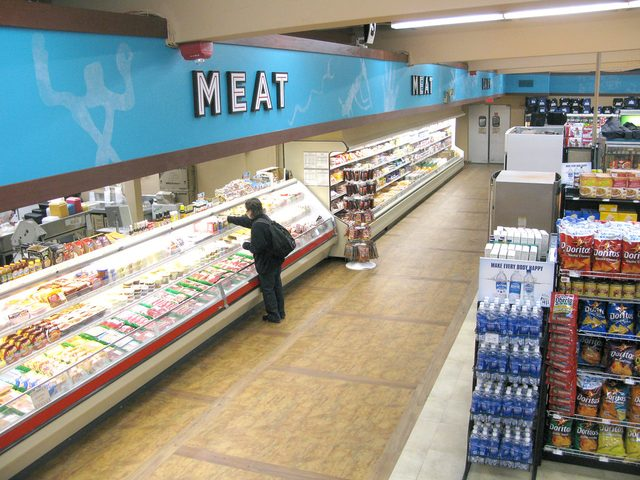

*Every checkout receipt is one transaction -- the raw material of market basket analysis. — Photo: Grand Canyon NPS, CC BY, via Flickr*



#### Reading a rule

$$\{\text{coffee}\} \;\rightarrow\; \{\text{sugar}\}$$

If a basket contains coffee, it tends to contain sugar. The left side is the antecedent (the if), the right side the consequent (the then); either side may hold more than one item.

- **The arrow is a direction.** {coffee} -> {sugar} and {sugar} -> {coffee} are two different rules, measured separately.
- **The arrow is not a cause.** The rule says the two items appear together more than chance would give, not that buying coffee makes anyone buy sugar.
- **A rule needs numbers** before a store acts on it: how common it is, how reliable, and whether it beats chance. Section 11.2.2 attaches all three.



#### What a store does with a rule

- **Place them together** — Put the consequent on the shelf or page next to the antecedent.
- **Advertise one to buyers of the other** — Show sugar to customers with coffee in the cart.
- **Bundle or discount the pair** — Profitable only when the association is real, which is what lift confirms.



## 11.2.2 · Support, confidence and lift -- recap

*Chapter 9's eight baskets*



#### Recap -- support, confidence and lift

*Section 9.4.3*

> **Definition.** **Association rule mining** finds “if X, then Y” patterns across a set of transactions, written `X -> Y` with X the **antecedent** (the if) and Y the **consequent** (the then) -- `{coffee} -> {sugar}` is a rule. **Support**$(X) = $ the share of transactions containing X, estimating $P(X)$. **Confidence**$(X \to Y) = \text{support}(X \cup Y) / \text{support}(X)$, the share of X's transactions that also hold Y, estimating $P(Y \mid X)$. **Lift**$(X \to Y) = \text{confidence}(X \to Y) / \text{support}(Y)$, comparing that confidence with how often Y happens anyway; lift $=1$ means no association at all.

Section 9.4.3's worked example was 8 baskets of apple, beer, rice, banana and milk:



#### The 8 baskets and their numbers

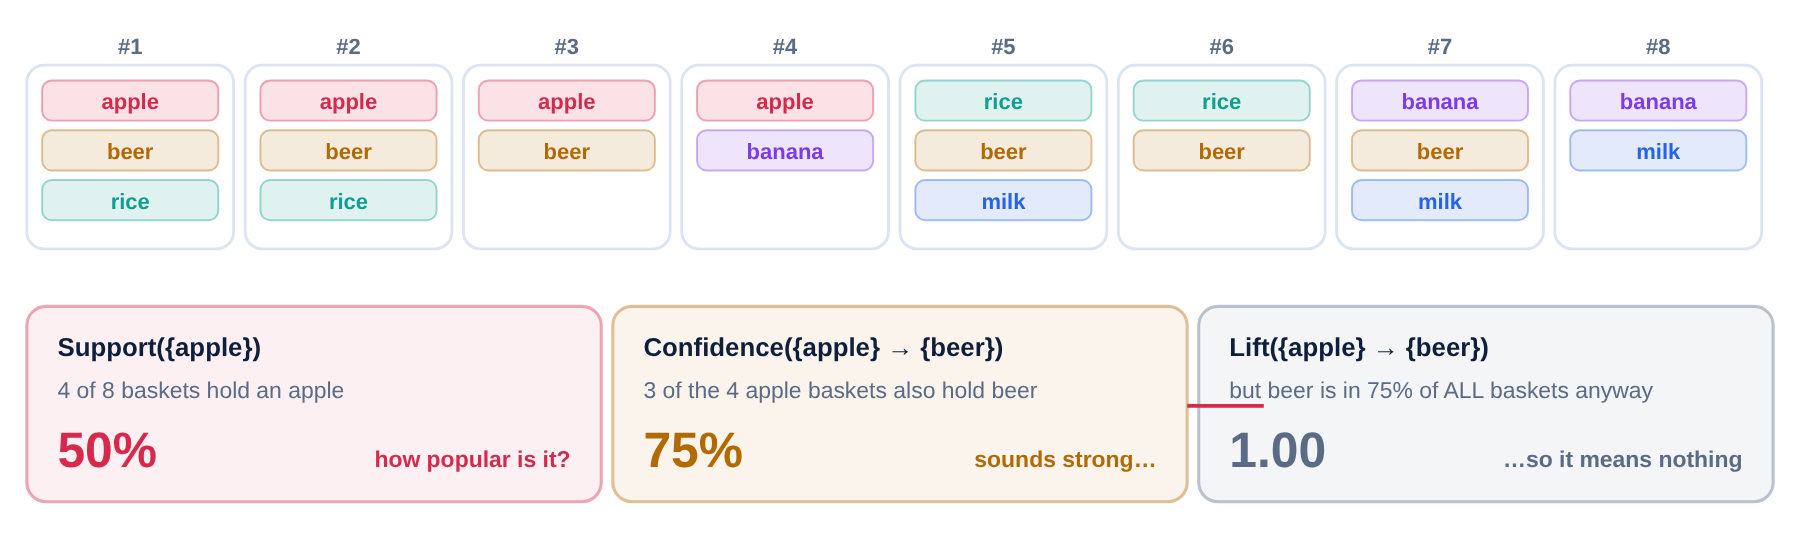

*Confidence and lift read the same baskets and disagree. Lift divides out how popular beer already is — which is the only reason you would not move the shelf.*



#### Confidence against lift

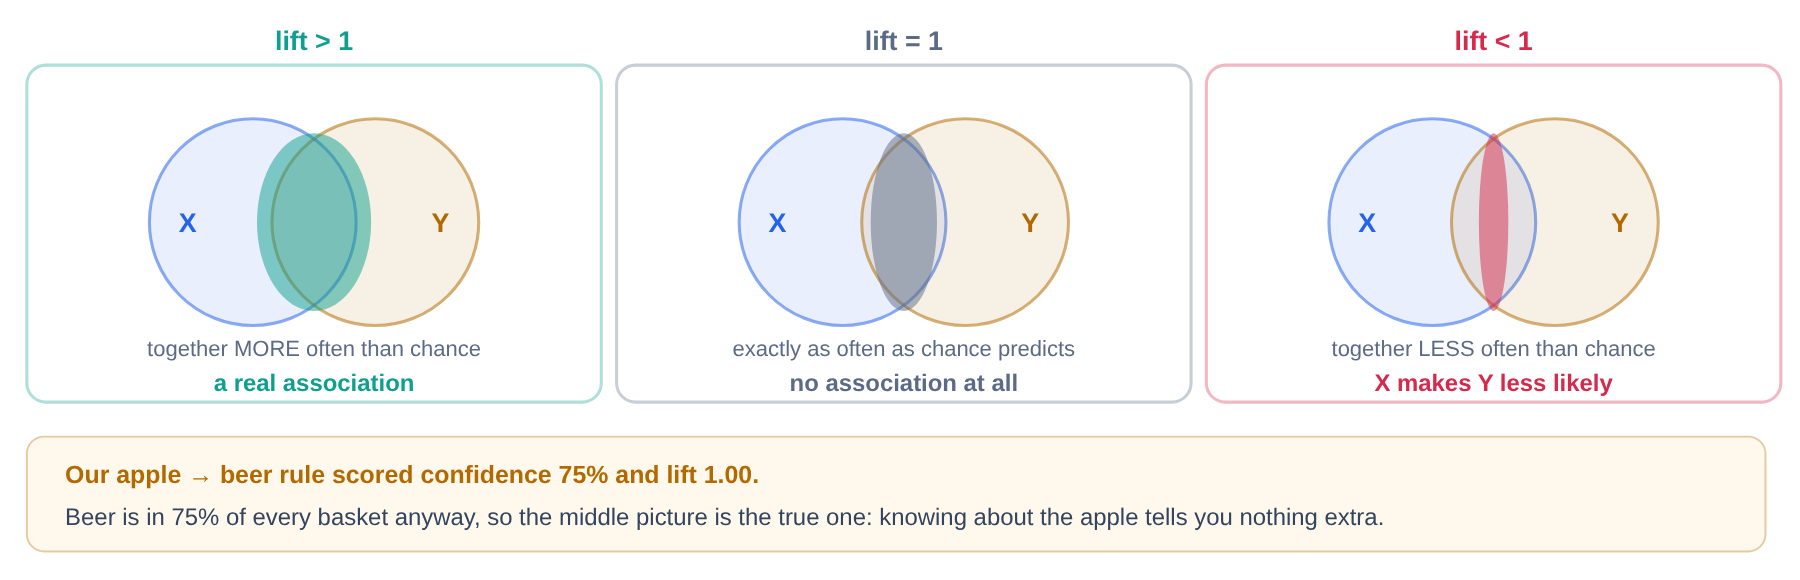

*Lift asks whether the overlap is bigger than you would get by chance alone. Confidence never asks that, which is how a popular item fools it.*

> **What lift caught, that confidence missed.** Confidence(apple → beer) = 75% sounds like a strong rule, but lift = 1.00 says beer is in 75% of every basket regardless of apples. The rule carries no information -- Section 9.4.3's caution applies again the moment a new confidence number looks impressive on its own.



#### The same 8 transactions

Section 9.4.3's list, unchanged, so the numbers below can be checked against the recap above.



> **Interpretation.** 0.375 -- the same value Section 9.4.3 computed by hand for support({apple, beer}).



In [2]:
transactions = [
    {"apple", "beer", "rice"}, {"apple", "beer", "rice"}, {"apple", "beer"}, {"apple", "banana"},
    {"rice", "beer", "milk"}, {"rice", "beer"}, {"banana", "beer", "milk"}, {"banana", "milk"},
]
def support(itemset, txns):
    return sum(1 for t in txns if itemset.issubset(t)) / len(txns)
support({"apple", "beer"}, transactions)

0.375

#### In the language of probability

Support estimates the probability of seeing an item set in a basket, $P(X)$. Confidence is the conditional probability of Y given X, $P(Y \mid X) = P(X \cap Y)/P(X)$. Lift is $P(Y \mid X)/P(Y)$: how much knowing X changes the chance of Y. Under independence $P(Y \mid X) = P(Y)$, so lift is exactly 1.



#### Lift, three ways

Three rules from the same 8 baskets -- one above 1, one at 1, one below -- computed with the same `support()` function, so each lift can be checked against the counts: banana is in 3 baskets and 2 of them hold milk; apple is in 4 and 3 hold beer; no apple basket holds milk.



> **Interpretation.** Reading the three lifts:
>
> - **banana -> milk, lift 1.78**: milk is in 37.5% of all baskets but in 67% of banana baskets -- banana raises the chance of milk, the pair goes together.
> - **apple -> beer, lift 1.00**: beer is as common with apples as without -- no association.
> - **apple -> milk, lift 0**: no apple basket holds milk, though 3 of 8 baskets do -- the pair avoids each other, and should not be bundled.
> - banana -> milk rests on 3 banana baskets: one more without milk would drop its confidence to 0.50. Lift has to be read beside support.



In [3]:
def lift(x, y, txns):
    confidence = support(x | y, txns) / support(x, txns)
    return confidence / support(y, txns)

pd.DataFrame({
    "rule": ["banana -> milk", "apple -> beer", "apple -> milk"],
    "lift": [round(lift({"banana"}, {"milk"}, transactions), 2),
             round(lift({"apple"}, {"beer"}, transactions), 2),
             round(lift({"apple"}, {"milk"}, transactions), 2)],
})

,rule,lift
0,banana -> milk,1.78
1,apple -> beer,1.00
2,apple -> milk,0.00


#### Where Section 11.2.2 leaves us

The three measures and the three readings of lift are in place on baskets small enough to count by hand. Section 11.2.3 applies them to every rule of a larger set of baskets at once, and turns the survivors into decisions.



## 11.2.3 · Every rule at once

*twelve grocery baskets, two thresholds, four decisions*



#### Where the tool changes what comes next

The 8-basket example is small enough to check by hand, which is exactly why it recapped Section 9.4.3 well. A market-basket question in practice involves many more baskets and many more candidate rules; the `support()` function above already generalizes, so the rest of Section 11.5 reuses it on a slightly larger, still hand-checkable set of transactions, and reads the results as business recommendations.



#### Twelve grocery transactions

Five items -- bread, butter, milk, eggs, coffee -- across 12 baskets, fixed so every student works from the same numbers.



In [4]:
groceries = [
    {"bread", "butter"}, {"bread", "butter", "milk"}, {"bread", "milk"}, {"bread", "butter", "eggs"},
    {"butter", "milk"}, {"bread", "butter", "milk", "eggs"}, {"coffee", "milk"}, {"bread", "eggs"},
    {"coffee", "bread"}, {"butter", "eggs"}, {"bread", "butter", "milk"}, {"coffee", "milk", "eggs"},
]
len(groceries)

12

#### Every rule between two single items

`itertools.permutations` lists every ordered pair of the five items -- ordered, because confidence(bread → butter) and confidence(butter → bread) are generally different numbers -- and support, confidence and lift are computed for each.



> **Interpretation.** 20 rules -- one for every ordered pair of the 5 items (`5 * 4 = 20`). Most of them describe a weak or accidental pattern; the next cell keeps only the ones worth a business's attention.



In [5]:
import itertools

items = sorted({item for basket in groceries for item in basket})
rows = []
for x, y in itertools.permutations(items, 2):
    supp_x = support({x}, groceries)
    supp_y = support({y}, groceries)
    supp_xy = support({x, y}, groceries)
    confidence = supp_xy / supp_x
    lift = confidence / supp_y
    rows.append({"rule": f"{x} -> {y}", "support": round(supp_xy, 3),
                 "confidence": round(confidence, 3), "lift": round(lift, 3)})
rules = pd.DataFrame(rows)
rules.shape

(20, 4)

#### Filtering to the rules worth reading

A minimum support of 0.25 (at least 3 of the 12 baskets) and a minimum confidence of 0.6 keep only rules that are both common enough to matter and reliable enough to act on, sorted by lift so the strongest associations come first.



> **Interpretation.** Reading the surviving rules:
>
> - **bread -> butter** and **butter -> bread** clear the bar with the highest confidence of the four (0.625 and 0.714) and a lift just above 1 -- these two items genuinely tend to appear together, not simply because both are common on their own.
> - **eggs -> butter** also clears the bar, with lift just above 1 -- a weaker version of the same pattern.
> - **eggs -> bread** clears the confidence bar but its lift is 0.900, just under 1 -- bread is, if anything, very slightly less likely once eggs are in the basket, not more.
> - **bread -> milk** and **milk -> bread** are common enough on support alone (each in a third of the baskets) but their confidence -- 0.500 and 0.571 -- falls short of the 0.6 bar, so neither is reported at all: common does not by itself mean reliable.
> - **coffee** does not appear in any surviving rule -- every rule that names it falls short on support, confidence, or both.



In [6]:
strong_rules = rules[(rules["support"] >= 0.25) & (rules["confidence"] >= 0.6)] \
    .sort_values("lift", ascending=False)
strong_rules

,rule,support,confidence,lift
0,bread -> butter,0.417,0.625,1.071
4,butter -> bread,0.417,0.714,1.071
13,eggs -> butter,0.250,0.600,1.029
12,eggs -> bread,0.250,0.600,0.900


#### Reading a rule as a business recommendation

An antecedent and a consequent translate directly into a shelf decision or a promotion, once lift confirms the rule is real:

- **Place bread and butter near each other**, or bundle them in a promotion -- the two rules with the highest lift in the filtered table, and each other's mirror image.
- **Treat eggs -> bread with caution** -- its confidence cleared the threshold, but a lift under 1 means bread is not actually more likely once eggs are bought; confidence alone would have recommended a shelf move that lift says is unjustified.
- **Do not chase bread -> milk as a discovery** -- it looked promising on support (both are common staples) but never reached the confidence bar in the first place, which is exactly the trap Section 9.4.3's caution about apple and beer warned against: a popular item can look associated with everything.



#### Where Section 11.2.3 leaves us

Support, confidence and lift now run over every rule of a set of baskets, and two thresholds plus lift turn a table of twenty candidate rules into the handful worth acting on.



## 11.2.4 · Glossary

*the new terms of this part*

Support, confidence and lift are defined in Chapter 9's own glossary (Section 9.4) and are not repeated here. This table holds only the vocabulary Part 11.2 adds.

| Term | Meaning |
|---|---|
| **Transaction** | One basket or receipt: the set of items bought together in one visit. |
| **Market basket analysis** | Association rule mining applied to shopping transactions. |
| **Antecedent / consequent** | The if / then halves of a rule X -> Y. |
| **Minimum support / confidence threshold** | The cutoffs a rule must clear before it is reported, so a search over many candidate rules returns only the ones worth reading. |



## 11.2.5 · Where this chapter leaves us

*the map of Chapters 9 to 11*

Unsupervised learning, across Chapters 9 and 11, now covers:

- **Clustering** -- K-means and hierarchical clustering, built by hand in Chapter 9 and applied through scikit-learn and SciPy in Part 11.1, standardized first and checked, where a label happens to exist, against it.
- **Association rules** -- support, confidence and lift, on 8 hand-checkable baskets and then on every rule of a larger set, filtered by a minimum support and confidence and ranked by lift.

> **From structure in numbers to meaning in text.** Every method in these two chapters answers a version of one question: what does the data look like on its own, with no answer key to learn from? Chapter 12 changes the kind of data the question is asked about -- from rows of numbers to text -- and asks what a piece of writing says, and how positively or negatively it says it.



## 11.2.6 · Homework

*the graded work, on 10 baskets*

The exercises continue Sections 11.2.2 and 11.2.3 on a new set of transactions, in the order this part taught the ideas: count support, compute confidence and lift, read a rule as a decision, then filter every rule. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** -- double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework data -- 10 party-snack baskets

*run this cell, but do not modify it*

Run this cell once and do not edit it. It defines `baskets`, a fixed list of 10 transactions over four items, and the `support()` function of Section 11.2.2 again, so the homework works even if the cells above were not run.



In [7]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
baskets = [
    {"chips", "salsa"}, {"chips", "salsa", "soda"}, {"chips", "soda"}, {"salsa", "guacamole"},
    {"chips", "salsa", "guacamole"}, {"soda", "guacamole"}, {"chips", "guacamole"},
    {"chips", "salsa", "soda", "guacamole"}, {"soda"}, {"chips", "soda", "guacamole"},
]
def support(itemset, txns):
    return sum(1 for t in txns if itemset.issubset(t)) / len(txns)
print("baskets:", len(baskets))

baskets: 10


#### Exercise 1 — Support by counting

Compute the support of each of the four items on its own, and of `{chips, salsa}`. Check one of the numbers by counting the baskets by hand.



In [8]:
# YOUR CODE HERE (Exercise 1)

#### Your answer -- Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — Confidence and lift of one rule

Compute the confidence and the lift of `chips -> salsa`. Say in one sentence what the lift means for this pair, using the reading of Section 11.2.2 (above 1, at 1, below 1).



In [9]:
# YOUR CODE HERE (Exercise 2)

#### Your answer -- Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — Is it worth acting on?

Compute support, confidence and lift for `soda -> guacamole`. Would you recommend placing the two together, or bundling them? Give the number that decides your answer.



In [10]:
# YOUR CODE HERE (Exercise 3)

#### Your answer -- Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Every rule, filtered

As Section 11.2.3 did for the twelve grocery baskets, list every rule between two of the four items (`itertools.permutations`), then keep the rules with support of at least 0.3 and confidence of at least 0.6, sorted by lift. Which surviving rule, if any, should a store not act on, and why?



In [11]:
# YOUR CODE HERE (Exercise 4)

#### Your answer -- Exercise 4

*Double-click this cell and type your answer here.*



#### Bonus -- a two-item antecedent

Compute the confidence and lift of `{chips, salsa} -> guacamole`, a rule whose antecedent holds two items. The `support()` function already accepts a set of any size. Is the rule stronger or weaker than `salsa -> guacamole` alone?



In [12]:
# YOUR CODE HERE (Bonus)

#### Your answer -- the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 4 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime -> Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

